## [문제] mushroom.csv 데이터를 사용하여 의사결정트리와 랜덤포레스트를 사용하여 분류하는 모델을 구현하시오.

### 제출할파일명: 홍길동_0430_DT_정확도_RT_정확도.ipynb

### <처리조건>
1. 하나의 파일에 의사결정트리와 랜덤포레스트 순서로 코드를 작성하고 두 부분을 구분할 수 있도록 제목을 적절히 작성한다.
2. 마지막에 정확도를 출력한다.
3. 정확도를 높이기 위하여 최적의 파라메터를 탐색하여 가장 최적의 정확도를 구한다.

### <데이터 설명>
### 첫번째 열(class) : 독성 유무
  - p(독성), e(식용) 
### 두번쨰 열(cap-shape) : 버섯의 머리 모양
  - 벨:b, 원뿔:c, 볼록:x, 평평:f, 혹:k, 오목:s
### 네번쨰열(cap-color) : 버섯의 머리 색
  - 갈색:n, 황갈색:b, 연한갈색:c, 회색:g,분홍색:p,녹색:r, 보라색:u,붉은색e,흰색:w, 노란색:y
### 나머진 생략…

## 데이터 불러오기

In [1]:
import pandas as pd

df = pd.read_csv('mushroom.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

## 레이블 인코딩

In [3]:
from sklearn.preprocessing import LabelEncoder

cols = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
        'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 
        'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 
        'stalk-surface-below-ring', 'stalk-color-above-ring', 
        'stalk-color-below-ring', 'veil-type', 'veil-color', 
        'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

df[cols] = df[cols].apply(LabelEncoder().fit_transform)

df.head(3)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3


In [4]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


## 데이터와 타깃 구분

In [5]:
data = df.iloc[:,1:]
target = df.iloc[:,0]

## 데이터 나누기

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, random_state=42, test_size=0.2)

# DecisionTreeClassifier

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [8]:
score = model.score(X_test, y_test)
print("정확도 :", score)

정확도 : 0.9747692307692307


피처 중요도 [0.         0.004531   0.         0.02819541 0.         0.
 0.         0.11521099 0.34222071 0.02640577 0.04128295 0.
 0.00282095 0.00292151 0.01778514 0.         0.         0.00251962
 0.         0.21247276 0.17908712 0.02454608]


(-1.0, 22.0)

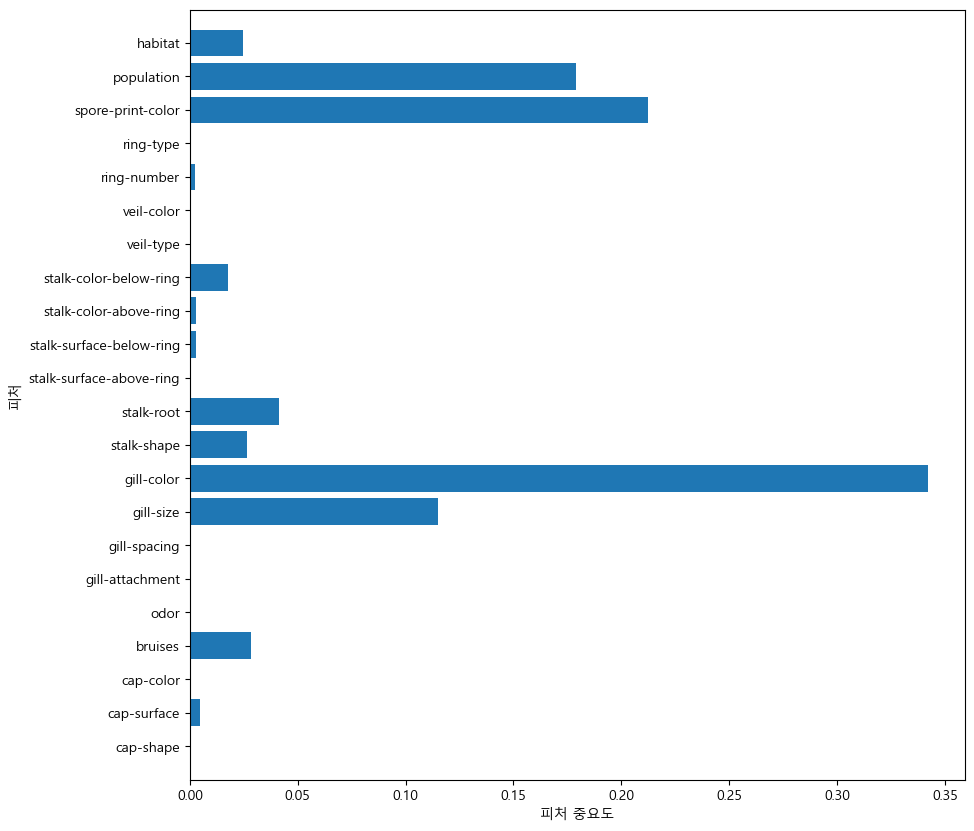

In [18]:
import numpy as np
import matplotlib.pyplot as plt

print("피처 중요도", model.feature_importances_)

plt.figure(figsize=(10,10))
plt.rcParams["font.family"] = "Malgun Gothic"
n_features = X_train.shape[1]
plt.barh(np.arange(n_features), model.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("피처 중요도")
plt.ylabel("피처")
plt.ylim(-1, n_features)

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

dec_model = DecisionTreeClassifier()
cv = KFold(n_splits=5, random_state=42, shuffle=True)
parameters = {'max_depth':[2,3,4,5,6,7,8,9,10],
             'criterion': ['gini', 'entropy'],
             'splitter':['best','random'],
             'min_samples_split':[2,3,4,5,6,7,8,9,10],
             'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10],
             'max_leaf_nodes':[None,2,3,4,5,6,7,8,9,10]}
model = GridSearchCV(estimator = dec_model,
                    param_grid = parameters,
                    cv =cv, verbose = 1,
                    n_jobs = -1, refit=True)
model.fit(X_train, y_train)

print("Best Estimator:\n", model.best_estimator_)
print("Best Params:\n", model.best_params_)
print("Best Score:\n", model.best_score_)

Fitting 5 folds for each of 32400 candidates, totalling 162000 fits
Best Estimator:
 DecisionTreeClassifier(max_depth=6, min_samples_leaf=7, splitter='random')
Best Params:
 {'criterion': 'gini', 'max_depth': 6, 'max_leaf_nodes': None, 'min_samples_leaf': 7, 'min_samples_split': 2, 'splitter': 'random'}
Best Score:
 1.0


In [15]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=7)
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print("정확도 :", score)

정확도 : 1.0


# RandomForestRegressor

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

forest = RandomForestClassifier(n_estimators=100)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

In [13]:
print('정확도 :', metrics.accuracy_score(y_test, y_pred))

정확도 : 1.0
